# Projeto 1 — Backtest "Hello World"
**Estratégia:** Reversão à média via Z-score de resíduo (com versão complexa usando filtro de regime e sizing por volatilidade).

## Grupo:
- Pedro De Lucca
- Henrique Badin 
- Luiz Pini
- Eduardo Selber

## Roteiro
1. Universo de ativos e período
2. Download e preparação dos dados
3. **Estratégia Simples** — Reversão à média por Z-score do desvio da média móvel
4. Backtest + métricas
5. Sensibilidade (janela, threshold, período)
6. **Estratégia Complexa** — Z-score + filtro de regime (tendência de longo prazo) + vol-targeting
7. Backtest + métricas da versão complexa
8. Sensibilidade da versão complexa
9. Comparativo final

> **Por que NÃO é cruzamento de SMA:** a estratégia não gera sinal pelo cruzamento de duas médias. O sinal vem do **desvio padronizado** do preço em relação a uma única média — é uma lógica de *mean reversion*, não de tendência por cruzamento.

In [16]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from itertools import product

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

## 1. Universo e obtenção de dados

**Universo:** 8 ações líquidas do Ibovespa de setores diferentes, para diversificação setorial.

**Período:** 2018-01-01 a 2024-12-31 (~7 anos, cobre pré-pandemia, crise COVID e pós).

O bloco abaixo tenta baixar dados reais via `yfinance`.

In [17]:
TICKERS = ['PETR4.SA', 'VALE3.SA', 'ITUB4.SA', 'BBDC4.SA',
          'ABEV3.SA', 'WEGE3.SA', 'MGLU3.SA', 'RENT3.SA']
START = '2018-01-01'
END   = '2024-12-31'

def download_data():
    try:
        data = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)['Close']
        if data.empty or data.isna().all().all():
            return None
        return data.dropna(how='all')
    except Exception as e:
        print(f'Falha no download real: {e}')
        return None
    
prices = download_data()
if prices is None:
    print('Não foi possível localizar os dados do Yahoo Finance')
else:
    print('>> Dados reais baixados do Yahoo Finance.')

# limpeza: só manter dias com dados em todos os ativos
prices = prices.dropna()
print(f'Shape: {prices.shape} | De {prices.index.min().date()} a {prices.index.max().date()}')
prices.head()

>> Dados reais baixados do Yahoo Finance.
Shape: (1738, 8) | De 2018-01-02 a 2024-12-30


Ticker,ABEV3.SA,BBDC4.SA,ITUB4.SA,MGLU3.SA,PETR4.SA,RENT3.SA,VALE3.SA,WEGE3.SA
Date,,,,,,,,
2018-01-02,14.3732,12.1921,15.4713,21.1350,4.4094,17.9081,21.6693,8.2026
2018-01-03,14.4064,12.2481,15.5771,20.8685,4.4493,18.1520,21.5395,8.0780
2018-01-04,14.3268,12.4491,15.9015,21.3695,4.4573,18.4116,21.6278,7.9994
2018-01-05,14.3799,12.5196,15.9473,20.9484,4.4840,18.1441,21.9654,8.0321
2018-01-08,14.3533,12.5160,15.8944,20.9511,4.5372,18.0575,22.4536,8.0977


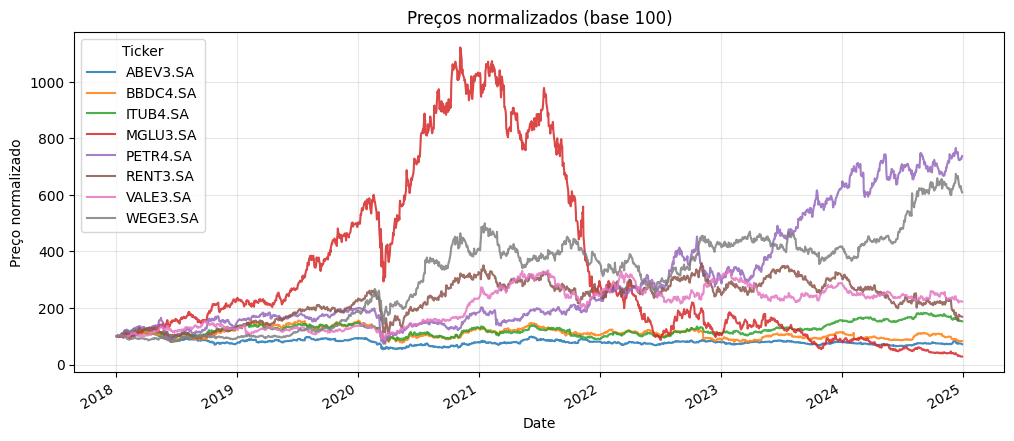

In [18]:
# Normalizar preços para começarem em 100 — facilita visualização
norm = prices / prices.iloc[0] * 100
norm.plot(title='Preços normalizados (base 100)', alpha=0.85)
plt.ylabel('Preço normalizado'); plt.grid(alpha=0.3); plt.show()

## 2. Estratégia Simples — Reversão à média via Z-score

### Intuição
Um ativo que se afasta muito da sua média recente tende, em horizontes curtos, a voltar. O Z-score mede **quantos desvios-padrão** o preço atual está longe da média móvel. Operamos *contra* o movimento:

- **Z muito negativo (caiu muito)** → compra (espera reversão para cima)
- **Z muito positivo (subiu muito)** → venda / fica de fora (se só-comprado)

### Regras
Para cada ativo $i$ no dia $t$, com janela $w$:

$$\mu_{i,t} = \mathrm{SMA}_w(P_{i,t}), \quad \sigma_{i,t} = \mathrm{std}_w(P_{i,t}), \quad z_{i,t} = \frac{P_{i,t} - \mu_{i,t}}{\sigma_{i,t}}$$

Sinal (long-only por simplicidade e realismo no mercado brasileiro):

- $z_{i,t} < -k_{\text{entry}}$ → **entra comprado**
- $z_{i,t} > -k_{\text{exit}}$ (ou $z \geq 0$) → **zera a posição**

### Alocação
Peso igual entre os ativos **atualmente com sinal ativo** (equal-weight dinâmico). Sobra caixa se menos ativos estão ativos.

### Execução
Sinal gerado em $t$ usando informação até $t$, executado em $t+1$ (evita look-ahead bias). Custos de 10 bps por lado em cada mudança de peso.

In [19]:
def zscore_signal(prices, window=20, k_entry=1.5, k_exit=0.0):
    """Retorna DataFrame booleano: True = posição comprada no dia.
    Lógica: entra quando z < -k_entry, sai quando z > -k_exit.
    Estado stateful (mantém posição entre entry e exit).
    """
    mu  = prices.rolling(window).mean()
    sig = prices.rolling(window).std()
    z   = (prices - mu) / sig
    
    positions = pd.DataFrame(False, index=prices.index, columns=prices.columns)
    for col in prices.columns:
        in_pos = False
        col_pos = np.zeros(len(prices), dtype=bool)
        zvals = z[col].values
        for i in range(len(prices)):
            if np.isnan(zvals[i]):
                continue
            if not in_pos and zvals[i] < -k_entry:
                in_pos = True
            elif in_pos and zvals[i] > -k_exit:
                in_pos = False
            col_pos[i] = in_pos
        positions[col] = col_pos
    return positions, z

pos_simple, z_simple = zscore_signal(prices, window=20, k_entry=1.5, k_exit=0.0)
print(f'Dias com pelo menos 1 posição aberta: {(pos_simple.sum(axis=1) > 0).mean():.1%}')
print(f'Média de ativos comprados simultaneamente: {pos_simple.sum(axis=1).mean():.2f}')

Dias com pelo menos 1 posição aberta: 79.5%
Média de ativos comprados simultaneamente: 2.51


## 3. Engine de backtest

**Funcionamento:**
1. Converte posições booleanas em pesos (equal-weight entre ativos ativos).
2. Defasagem de 1 dia no peso (execução em $t+1$).
3. Retorno da carteira = soma dos (peso × retorno) menos custo de transação nas mudanças de peso.
4. Benchmark: equal-weight buy-and-hold do mesmo universo.

In [20]:
TRADING_DAYS = 252

def backtest(prices, positions, cost_bps=10):
    """
    prices: DataFrame de preços
    positions: DataFrame booleano (ou numérico 0/1) de sinais
    cost_bps: custo por lado em basis points (10 bps = 0.10%)
    """
    rets = prices.pct_change().fillna(0)
    pos = positions.astype(float)
    # Equal-weight dinâmico entre ativos ativos
    n_active = pos.sum(axis=1).replace(0, np.nan)
    weights = pos.div(n_active, axis=0).fillna(0)
    # Execução em t+1
    weights_exec = weights.shift(1).fillna(0)
    # Turnover: variação absoluta de pesos
    turnover = (weights_exec - weights_exec.shift(1).fillna(0)).abs().sum(axis=1)
    # Custo aplicado à mudança
    cost = turnover * (cost_bps / 10_000)
    # Retorno da estratégia
    port_ret = (weights_exec * rets).sum(axis=1) - cost
    equity = (1 + port_ret).cumprod()
    return pd.DataFrame({
        'return': port_ret,
        'equity': equity,
        'n_active': pos.sum(axis=1),
        'turnover': turnover,
    })

def benchmark_ew(prices):
    rets = prices.pct_change().fillna(0)
    port = rets.mean(axis=1)  # equal weight buy & hold
    return pd.DataFrame({'return': port, 'equity': (1+port).cumprod()})

def metrics(returns, name='Estratégia'):
    r = returns.dropna()
    if len(r) == 0 or r.std() == 0:
        return pd.Series({'CAGR':0,'Vol':0,'Sharpe':0,'MaxDD':0,'Calmar':0,'WinRate':0}, name=name)
    n = len(r)
    cagr = (1+r).prod()**(TRADING_DAYS/n) - 1
    vol = r.std() * np.sqrt(TRADING_DAYS)
    sharpe = (r.mean()*TRADING_DAYS) / vol if vol > 0 else 0
    eq = (1+r).cumprod()
    dd = (eq / eq.cummax() - 1).min()
    calmar = cagr / abs(dd) if dd < 0 else np.nan
    winrate = (r > 0).mean()
    return pd.Series({
        'CAGR': cagr, 'Vol': vol, 'Sharpe': sharpe,
        'MaxDD': dd, 'Calmar': calmar, 'WinRate': winrate
    }, name=name)

# Rodar backtest simples
bt_simple = backtest(prices, pos_simple, cost_bps=10)
bench = benchmark_ew(prices)

comp_simple = pd.concat([
    metrics(bt_simple['return'], 'Reversão Simples'),
    metrics(bench['return'], 'Benchmark EW B&H'),
], axis=1)
comp_simple

,Reversão Simples,Benchmark EW B&H
CAGR,-0.0300,0.1247
Vol,0.3171,0.2691
Sharpe,0.0627,0.5726
MaxDD,-0.6163,-0.4299
Calmar,-0.0487,0.2901
WinRate,0.3843,0.5236


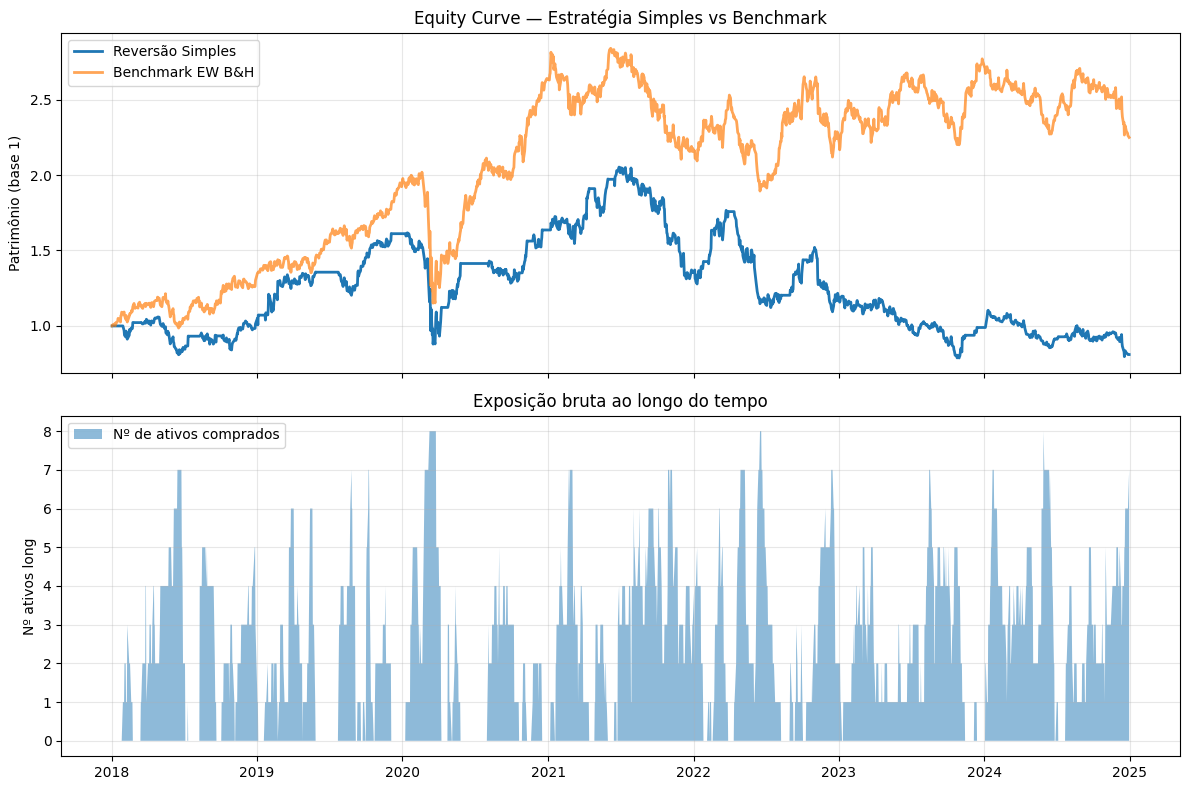

In [21]:
# Gráfico: equity curves
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(bt_simple['equity'], label='Reversão Simples', lw=2)
axes[0].plot(bench['equity'], label='Benchmark EW B&H', lw=2, alpha=0.7)
axes[0].set_title('Equity Curve — Estratégia Simples vs Benchmark')
axes[0].set_ylabel('Patrimônio (base 1)'); axes[0].legend(); axes[0].grid(alpha=0.3)

# exposição ao longo do tempo
axes[1].fill_between(bt_simple.index, 0, bt_simple['n_active'], alpha=0.5, label='Nº de ativos comprados')
axes[1].set_ylabel('Nº ativos long'); axes[1].set_title('Exposição bruta ao longo do tempo')
axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()

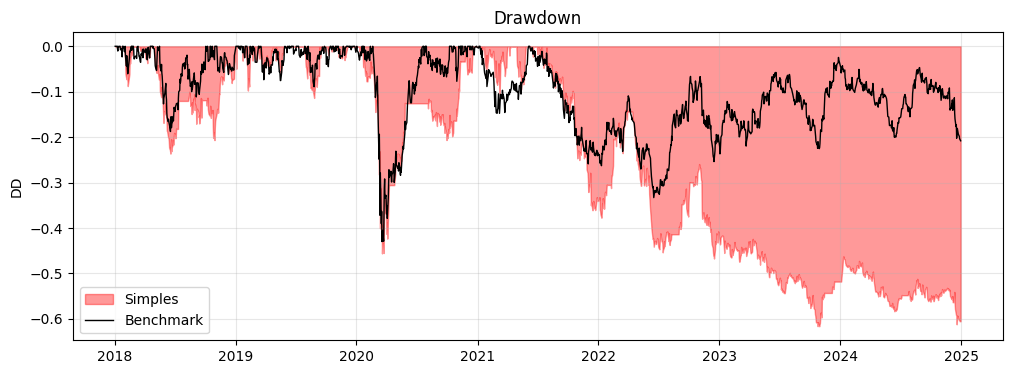

In [22]:
# Drawdown
def drawdown(eq):
    return eq / eq.cummax() - 1

plt.figure(figsize=(12,4))
plt.fill_between(bt_simple.index, drawdown(bt_simple['equity']), 0,
                 alpha=0.4, color='red', label='Simples')
plt.plot(drawdown(bench['equity']), color='black', lw=1, label='Benchmark')
plt.title('Drawdown'); plt.ylabel('DD'); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 4. Testes de sensibilidade — Estratégia Simples

Vamos variar:
- **Janela** $w \in \{10, 15, 20, 30, 40, 60\}$
- **Threshold de entrada** $k_{\text{entry}} \in \{1.0, 1.5, 2.0, 2.5\}$
- **Sensibilidade temporal:** mesma estratégia em sub-períodos diferentes (walk-forward simplificado)

In [23]:
# Grid de parâmetros
windows = [10, 15, 20, 30, 40, 60]
entries = [1.0, 1.5, 2.0, 2.5]

rows = []
for w, k in product(windows, entries):
    pos, _ = zscore_signal(prices, window=w, k_entry=k, k_exit=0.0)
    bt = backtest(prices, pos, cost_bps=10)
    m = metrics(bt['return'])
    rows.append({'window': w, 'k_entry': k, **m.to_dict()})

sens_simple = pd.DataFrame(rows)
sens_simple.head()

,window,k_entry,CAGR,Vol,Sharpe,MaxDD,Calmar,WinRate
0,10,1.0000,0.0441,0.3221,0.2956,-0.4697,0.0940,0.4114
1,10,1.5000,-0.0618,0.3081,-0.0520,-0.5168,-0.1196,0.3763
2,10,2.0000,0.1383,0.3033,0.5788,-0.4350,0.3179,0.2883
3,10,2.5000,-0.0612,0.2069,-0.1976,-0.4991,-0.1227,0.0731
4,15,1.0000,-0.0437,0.3205,0.0212,-0.5490,-0.0796,0.4120


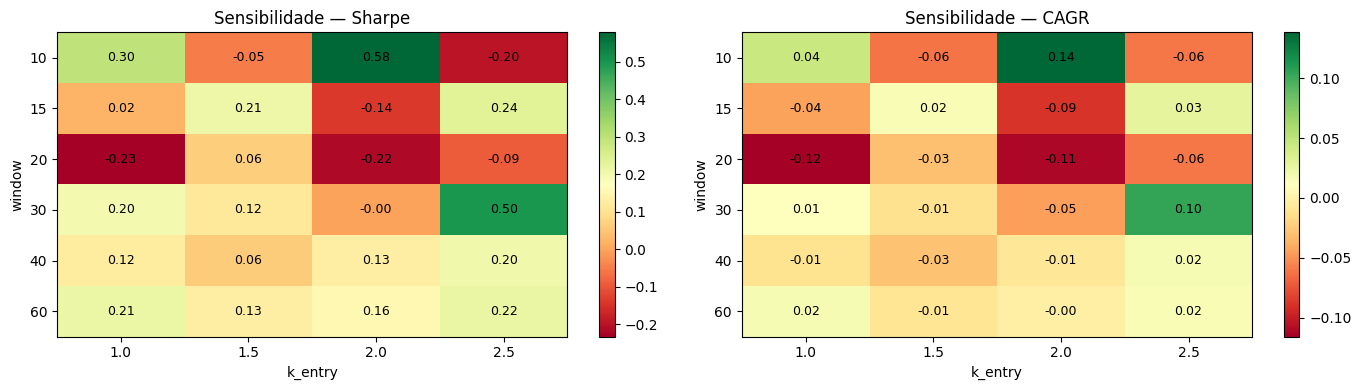

In [24]:
# Heatmaps: Sharpe e CAGR
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric in zip(axes, ['Sharpe', 'CAGR']):
    pivot = sens_simple.pivot(index='window', columns='k_entry', values=metric)
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn')
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
    ax.set_xlabel('k_entry'); ax.set_ylabel('window')
    ax.set_title(f'Sensibilidade — {metric}')
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f'{pivot.values[i,j]:.2f}', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

In [25]:
# Sensibilidade temporal: dividir em janelas de ~2 anos e rodar a config base
def period_slices(df, n=3):
    idx = df.index
    splits = np.array_split(idx, n)
    return [(s[0], s[-1]) for s in splits]

base_w, base_k = 20, 1.5
rows = []
for start, end in period_slices(prices, n=3):
    p = prices.loc[start:end]
    pos, _ = zscore_signal(p, window=base_w, k_entry=base_k)
    bt = backtest(p, pos)
    bh = benchmark_ew(p)
    rows.append({
        'periodo': f'{start.date()} → {end.date()}',
        **{f'strat_{k}':v for k,v in metrics(bt['return']).items()},
        **{f'bench_{k}':v for k,v in metrics(bh['return']).items()},
    })
temporal_simple = pd.DataFrame(rows)
temporal_simple[['periodo','strat_CAGR','strat_Sharpe','strat_MaxDD','bench_CAGR','bench_Sharpe']]

,periodo,strat_CAGR,strat_Sharpe,strat_MaxDD,bench_CAGR,bench_Sharpe
0,2018-01-02 → 2020-05-07,0.0744,0.3802,-0.4559,0.1803,0.6590
1,2020-05-08 → 2022-09-02,-0.0592,-0.0805,-0.4536,0.2225,0.9547
2,2022-09-05 → 2024-12-30,-0.2207,-0.8185,-0.4820,-0.0302,-0.0469


## 5. Estratégia Complexa

Problemas típicos da reversão-à-média simples:
1. Em **tendências fortes** (baixa), você compra a faca caindo — Z fica persistentemente negativo.
2. **Concentração**: se 1 ativo só está ativo, a carteira vira 100% nele.
3. **Volatilidades muito diferentes** entre ativos distorcem o equal-weight.

### Melhorias implementadas

1. **Filtro de regime (trend filter):** só compra se o preço estiver acima da SMA de 200 dias — evita pegar faca caindo em bear market. Reversão à média funciona melhor quando o ativo está numa tendência de alta mais ampla.

2. **Volatility targeting por ativo:** peso de cada ativo é inversamente proporcional à sua vol realizada (inverse-volatility weighting), depois normalizado pelo número de ativos ativos. Ativos mais voláteis recebem menos peso.

3. **Cap de exposição bruta:** exposição total limitada a 100% (quando poucos ativos estão ativos, não alavanca além disso; mas também evita o caso degenerado de um único ativo tomar 100%).

4. **Stop por tempo (time stop):** se a posição não reverter em $T_{\max}$ dias, zera. Evita ficar preso em trades que viraram tendência.

In [26]:
def zscore_signal_complex(prices, window=20, k_entry=1.5, k_exit=0.0,
                         trend_window=200, time_stop=30):
    """Sinal de reversão + filtro de regime + time stop."""
    mu  = prices.rolling(window).mean()
    sig = prices.rolling(window).std()
    z   = (prices - mu) / sig
    trend_sma = prices.rolling(trend_window).mean()
    is_uptrend = prices > trend_sma  # filtro de regime
    
    positions = pd.DataFrame(False, index=prices.index, columns=prices.columns)
    for col in prices.columns:
        in_pos = False
        days_in = 0
        col_pos = np.zeros(len(prices), dtype=bool)
        zvals = z[col].values
        uptrend = is_uptrend[col].values
        for i in range(len(prices)):
            if np.isnan(zvals[i]) or np.isnan(uptrend[i]):
                continue
            if not in_pos:
                if zvals[i] < -k_entry and uptrend[i]:
                    in_pos = True; days_in = 0
            else:
                days_in += 1
                # saída normal, time stop, ou quebra de regime
                if zvals[i] > -k_exit or days_in >= time_stop or not uptrend[i]:
                    in_pos = False; days_in = 0
            col_pos[i] = in_pos
        positions[col] = col_pos
    return positions, z

def backtest_complex(prices, positions, vol_window=20, cost_bps=10, max_gross=1.0):
    """Backtest com inverse-vol weighting entre ativos ativos + cap de exposição."""
    rets = prices.pct_change().fillna(0)
    pos  = positions.astype(float)
    # vol realizada para sizing
    vol = rets.rolling(vol_window).std().replace(0, np.nan)
    inv_vol = (1.0 / vol).fillna(0)
    raw_w = pos * inv_vol
    sum_w = raw_w.sum(axis=1).replace(0, np.nan)
    weights = raw_w.div(sum_w, axis=0).fillna(0)
    # cap de exposição bruta (normalizada já soma 1 quando há ao menos 1 ativo)
    gross = weights.abs().sum(axis=1)
    scale = (max_gross / gross).where(gross > max_gross, 1.0).fillna(1.0)
    weights = weights.mul(scale, axis=0)
    # execução t+1
    w_exec = weights.shift(1).fillna(0)
    turnover = (w_exec - w_exec.shift(1).fillna(0)).abs().sum(axis=1)
    cost = turnover * (cost_bps / 10_000)
    port_ret = (w_exec * rets).sum(axis=1) - cost
    equity = (1 + port_ret).cumprod()
    return pd.DataFrame({
        'return': port_ret, 'equity': equity,
        'n_active': pos.sum(axis=1), 'gross': w_exec.abs().sum(axis=1),
        'turnover': turnover,
    })

pos_cplx, _ = zscore_signal_complex(prices, window=20, k_entry=1.5, k_exit=0.0,
                                    trend_window=200, time_stop=30)
bt_cplx = backtest_complex(prices, pos_cplx, vol_window=20, cost_bps=10)
print(f'Dias expostos: {(bt_cplx["gross"] > 0).mean():.1%}')
print(f'Exposição média (quando exposto): {bt_cplx[bt_cplx["gross"]>0]["gross"].mean():.2f}')

Dias expostos: 44.5%
Exposição média (quando exposto): 1.00


## 6. Resultados da versão complexa

In [27]:
comp_all = pd.concat([
    metrics(bt_simple['return'], 'Simples'),
    metrics(bt_cplx['return'],   'Complexa'),
    metrics(bench['return'],     'Benchmark EW B&H'),
], axis=1)
print('Comparativo de métricas:')
comp_all

Comparativo de métricas:


,Simples,Complexa,Benchmark EW B&H
CAGR,-0.0300,0.0221,0.1247
Vol,0.3171,0.2427,0.2691
Sharpe,0.0627,0.2146,0.5726
MaxDD,-0.6163,-0.5329,-0.4299
Calmar,-0.0487,0.0414,0.2901
WinRate,0.3843,0.2227,0.5236


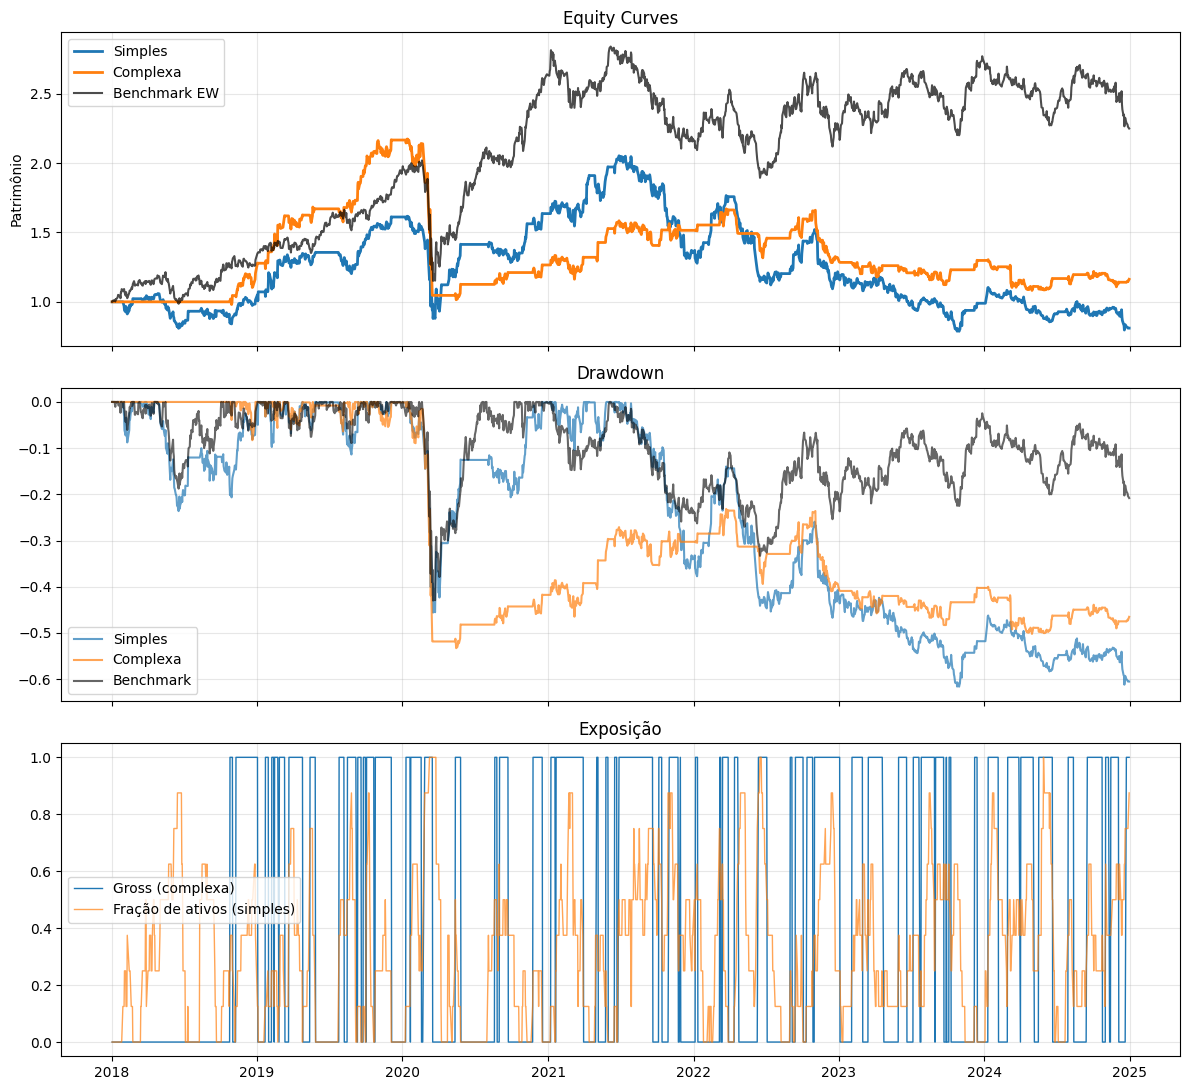

In [28]:
# Gráficos comparativos
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
axes[0].plot(bt_simple['equity'], label='Simples', lw=2)
axes[0].plot(bt_cplx['equity'], label='Complexa', lw=2)
axes[0].plot(bench['equity'], label='Benchmark EW', lw=1.5, alpha=0.7, color='black')
axes[0].set_title('Equity Curves'); axes[0].set_ylabel('Patrimônio')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(drawdown(bt_simple['equity']), label='Simples', alpha=0.7)
axes[1].plot(drawdown(bt_cplx['equity']), label='Complexa', alpha=0.7)
axes[1].plot(drawdown(bench['equity']), label='Benchmark', color='black', alpha=0.6)
axes[1].set_title('Drawdown'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(bt_cplx['gross'], label='Gross (complexa)', lw=1)
axes[2].plot(bt_simple['n_active']/len(prices.columns), label='Fração de ativos (simples)',
             lw=1, alpha=0.7)
axes[2].set_title('Exposição'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Sensibilidade — Estratégia Complexa

Parâmetros adicionais: `trend_window`, `time_stop`, `vol_window`.

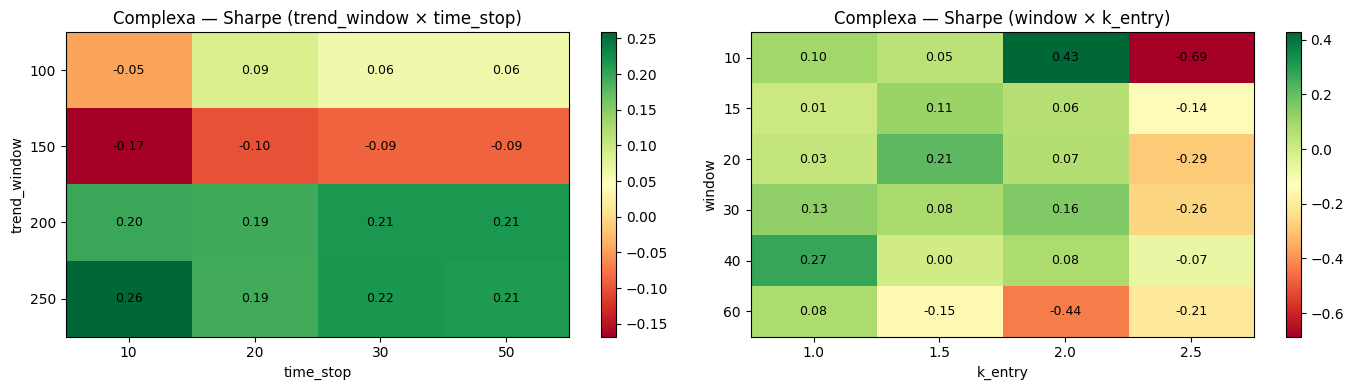

In [29]:
# Sensibilidade nos dois parâmetros novos (fixando window=20, k=1.5)
trend_windows = [100, 150, 200, 250]
time_stops    = [10, 20, 30, 50]

rows = []
for tw, ts in product(trend_windows, time_stops):
    pos, _ = zscore_signal_complex(prices, 20, 1.5, 0.0, trend_window=tw, time_stop=ts)
    bt = backtest_complex(prices, pos)
    m = metrics(bt['return'])
    rows.append({'trend_window': tw, 'time_stop': ts, **m.to_dict()})
sens_cplx_a = pd.DataFrame(rows)

# Grid também em w e k com os parâmetros de regime fixos
rows = []
for w, k in product(windows, entries):
    pos, _ = zscore_signal_complex(prices, window=w, k_entry=k, k_exit=0.0,
                                   trend_window=200, time_stop=30)
    bt = backtest_complex(prices, pos)
    m = metrics(bt['return'])
    rows.append({'window': w, 'k_entry': k, **m.to_dict()})
sens_cplx_b = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (df, ix, col) in zip(axes, [
        (sens_cplx_a, 'trend_window', 'time_stop'),
        (sens_cplx_b, 'window', 'k_entry')]):
    pivot = df.pivot(index=ix, columns=col, values='Sharpe')
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn')
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
    ax.set_xlabel(col); ax.set_ylabel(ix); ax.set_title(f'Complexa — Sharpe ({ix} × {col})')
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f'{pivot.values[i,j]:.2f}', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

In [30]:
# Sensibilidade temporal da estratégia complexa
rows = []
for start, end in period_slices(prices, n=3):
    p = prices.loc[start:end]
    pos, _ = zscore_signal_complex(p, 20, 1.5, 0.0, trend_window=200, time_stop=30)
    bt = backtest_complex(p, pos)
    bh = benchmark_ew(p)
    rows.append({
        'periodo': f'{start.date()} → {end.date()}',
        **{f'strat_{k}':v for k,v in metrics(bt['return']).items()},
        **{f'bench_{k}':v for k,v in metrics(bh['return']).items()},
    })
temporal_cplx = pd.DataFrame(rows)
temporal_cplx[['periodo','strat_CAGR','strat_Sharpe','strat_MaxDD','bench_CAGR','bench_Sharpe']]

,periodo,strat_CAGR,strat_Sharpe,strat_MaxDD,bench_CAGR,bench_Sharpe
0,2018-01-02 → 2020-05-07,0.0199,0.2264,-0.5185,0.1803,0.6590
1,2020-05-08 → 2022-09-02,0.0988,0.6175,-0.2114,0.2225,0.9547
2,2022-09-05 → 2024-12-30,-0.0169,-0.0582,-0.1700,-0.0302,-0.0469


## 8. Discussão e conclusão

### O que olhar na apresentação

**Estratégia simples:**
- Entra comprado em ativos com preço anormalmente abaixo da média de curto prazo; sai quando volta à média.
- Exposição varia (fica em caixa quando ninguém está "esticado" para baixo).
- Concentra risco em poucos ativos em alguns períodos.

**Estratégia complexa:**
- Filtro de regime (SMA 200) evita comprar faca caindo em bear markets — esperado reduzir drawdown.
- Inverse-vol weighting tende a suavizar retornos (reduz vol e dá peso maior a ativos estáveis).
- Time stop reduz exposição a trades que "viraram tendência".

### Sensibilidade — o que esperamos ver
- **Estratégia frágil**: heatmap colorido de forma caótica (alta variação de Sharpe entre células vizinhas). Isso sugere overfitting a parâmetros.
- **Estratégia robusta**: região contígua de bom desempenho (plateau). Preferível mesmo que o pico absoluto seja menor.
- **Sensibilidade temporal**: se performance muda muito entre subperíodos, a estratégia captura um regime específico, não um edge persistente.

### Limitações honestas
- **Long-only** — no Brasil é realista, mas deixa dinheiro na mesa em bear markets.
- **Custos simplificados** (10 bps) — não modela slippage, impacto de mercado ou IOF.
- **Sem dividendos** separados (usamos preço ajustado).
- **Universo pequeno e estático** — survivorship bias: só escolhemos ações que existiam e eram líquidas em 2024.
- **Sem walk-forward real** — a sensibilidade temporal aqui é um teste de estabilidade, não uma otimização out-of-sample de verdade.

### Próximos passos possíveis
1. Walk-forward real: reotimizar parâmetros a cada N meses em dados passados e aplicar out-of-sample.
2. Incluir short ou pair-trading (reversão relativa entre pares cointegrados).
3. Sizing por Kelly fracionário ou risk parity cross-asset.
4. Testar o mesmo framework em outros universos (ETFs setoriais, moedas) para ver se o edge é específico ou geral.